In [12]:
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt



root_path = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / "utils").exists()), None)
if root_path is None:
    raise FileNotFoundError("Could not locate project root containing 'utils' directory")
sys.path.append(str(root_path))

from utils.helpers import load_data
from utils.CBM_scores import add_part2_cbm_score

In [13]:
df = load_data("../data/CBM_format/IN1020_2025konte_CBM.csv")
df.head()

Data loaded successfully from ../data/CBM_format/IN1020_2025konte_CBM.csv


,student_id,max_question_score,question_number,question_title,question_duration_sec,auto_score_per_question,auto_score,answer_alternative,confidence_level
0,5,1.0,2.1,H25K - CBA - PC,32,1.0,18.0,1,1.0
1,5,1.0,2.1,H25K - CBA - PC,32,1.0,18.0,4,0.0
2,5,1.0,2.1,H25K - CBA - PC,32,1.0,18.0,3,0.0
3,5,1.0,2.1,H25K - CBA - PC,32,1.0,18.0,5,0.0
4,5,1.0,2.1,H25K - CBA - PC,32,1.0,18.0,2,0.0


In [14]:
df_CBM1 = add_part2_cbm_score(df)
df_CBM1[["student_id", "part2_cbm_score"]].drop_duplicates(subset=["student_id"]).head()

,student_id,part2_cbm_score
0,5,9.0
75,22,18.0
150,10,6.5
225,52,10.5
300,35,18.0


### Plot total auto score

Number of unique students: 68


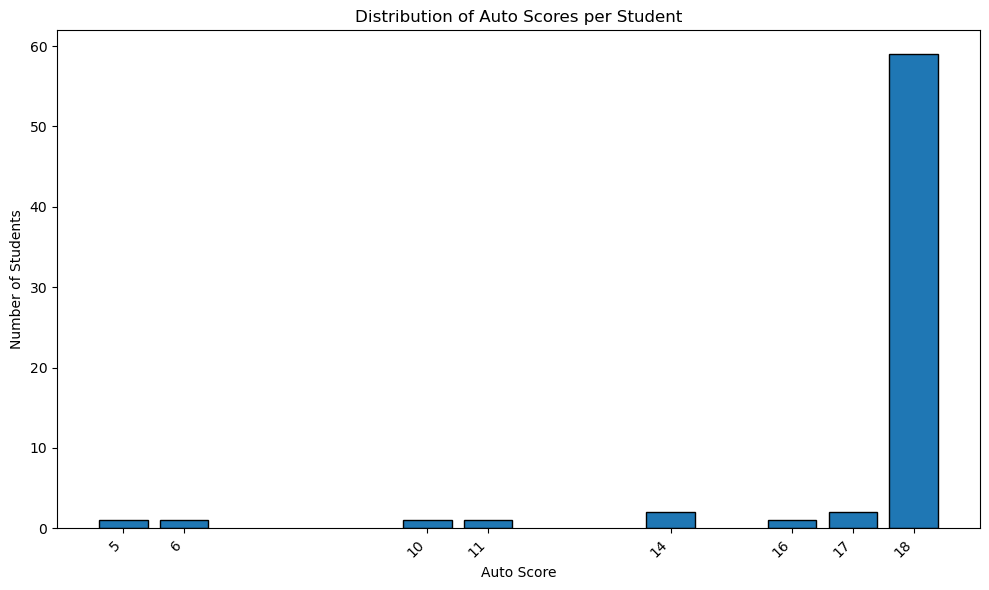

In [15]:
student_scores = df.drop_duplicates(subset=["student_id"])[["student_id", "auto_score"]]

print(f"Number of unique students: {len(student_scores)}")

#By using value_counts().sort_index(), each bar is drawn at the exact score value that students actually received
score_counts = student_scores["auto_score"].value_counts().sort_index()

plt.figure(figsize=(10, 6))
plt.bar(score_counts.index, score_counts.values, width=0.8, edgecolor="black", align="center")
plt.xticks(score_counts.index, rotation=45, ha="right")
plt.xlabel("Auto Score")
plt.ylabel("Number of Students")
plt.title("Distribution of Auto Scores per Student")
plt.tight_layout()
plt.show()


Number of unique students: 68


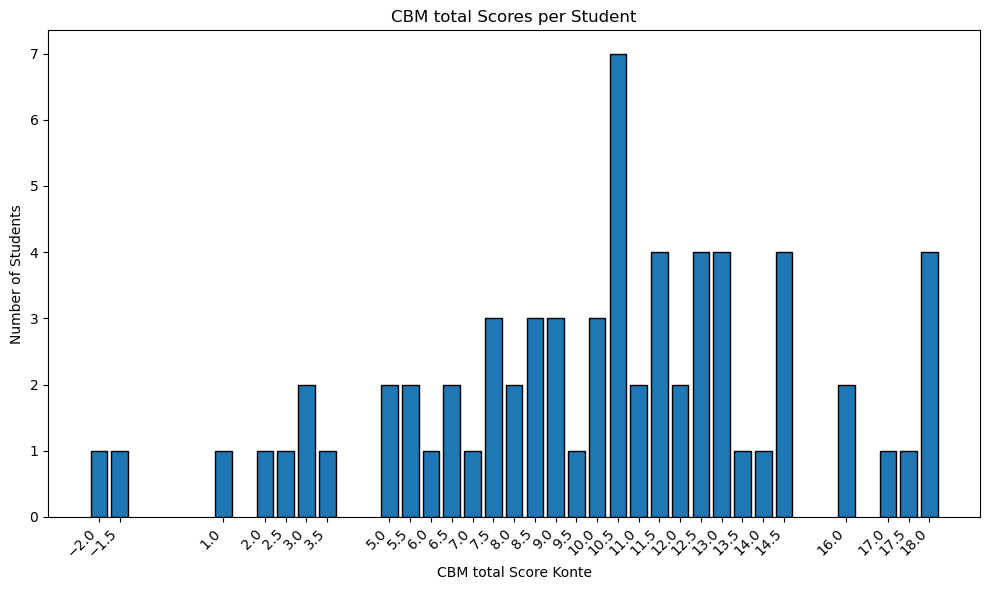

In [16]:
student_scores = df_CBM1.drop_duplicates(subset=["student_id"])[["student_id", "part2_cbm_score"]]

print(f"Number of unique students: {len(student_scores)}")

#By using value_counts().sort_index(), each bar is drawn at the exact score value that students actually received
score_counts = student_scores["part2_cbm_score"].value_counts().sort_index()

plt.figure(figsize=(10, 6))
plt.bar(score_counts.index, score_counts.values, width=0.4, edgecolor="black", align="center")
plt.xticks(score_counts.index, rotation=45, ha="right")
plt.xlabel("CBM total Score Konte")
plt.ylabel("Number of Students")
plt.title("CBM total Scores per Student")
plt.tight_layout()
plt.show()
